In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# --------------------- Import VQNiche ---------------------
from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche.utils.type_conversions import *
from vqniche.plotting import *

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [4]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad
import squidpy as sq

import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj

# --------------------- Display Settings ---------------------
# display setting all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# One Batch

In [5]:
def one_batch_train_val_test_splits(data_batch):
    # Extract the data attributes
    print("Extracting data attributes...")
    print(f"Data batch keys: {list(data_batch.keys())}")
    print(f"Number of nodes: {data_batch.x.shape[0]}")
    print(f"Number of features: {data_batch.x.shape[1]}")
    print(f"Number of edges: {data_batch.edge_index.shape[1]}")

    # Get coordinates and masks
    xy_coords = data_batch.xy_coordinates.numpy()
    train_mask = data_batch.train_mask.numpy()
    val_mask = data_batch.val_mask.numpy()
    test_mask = data_batch.test_mask.numpy()

    print(f"Train nodes: {train_mask.sum()}")
    print(f"Val nodes: {val_mask.sum()}")
    print(f"Test nodes: {test_mask.sum()}")
    print(f"Total nodes: {len(train_mask)}")

    # Create the visualization
    plt.figure(figsize=(12, 8))

    # Plot points colored by their split
    train_coords = xy_coords[train_mask]
    val_coords = xy_coords[val_mask]
    test_coords = xy_coords[test_mask]

    plt.scatter(train_coords[:, 0], train_coords[:, 1], 
            c='lightgrey', alpha=0.6, s=1, label=f'Train ({len(train_coords)})')
    plt.scatter(val_coords[:, 0], val_coords[:, 1], 
            c='blue', alpha=0.8, s=1, label=f'Validation ({len(val_coords)})')
    plt.scatter(test_coords[:, 0], test_coords[:, 1], 
            c='red', alpha=0.8, s=1, label=f'Test ({len(test_coords)})')

    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.title('Spatial Distribution of Train/Validation/Test Splits')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')

    # Add some statistics
    total_nodes = len(train_mask)
    train_pct = (train_mask.sum() / total_nodes) * 100
    val_pct = (val_mask.sum() / total_nodes) * 100
    test_pct = (test_mask.sum() / total_nodes) * 100

    plt.figtext(0.02, 0.02, f'Split ratios - Train: {train_pct:.1f}% | Val: {val_pct:.1f}% | Test: {test_pct:.1f}%', 
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

    # Optional: Create a second plot showing the spatial density of each split
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    splits = [('Train', train_mask, 'green'), ('Validation', val_mask, 'blue'), ('Test', test_mask, 'red')]

    for i, (split_name, mask, color) in enumerate(splits):
        coords = xy_coords[mask]
        axes[i].scatter(coords[:, 0], coords[:, 1], c=color, alpha=0.6, s=1)
        axes[i].set_title(f'{split_name} Set ({len(coords)} nodes)')
        axes[i].set_xlabel('X coordinate')
        axes[i].set_ylabel('Y coordinate')
        axes[i].grid(True, alpha=0.3)
        axes[i].axis('equal')

    plt.tight_layout()
    plt.show()

In [6]:
cfg_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b-batch11_1p_vqniche_graphsage.yaml")
with open(cfg_file, 'r') as f:
    cfg = yaml.safe_load(f)

## Random Split

In [7]:
# Deep copy to preserve original
rdn_cfg = copy.deepcopy(cfg)

# Update nested keys
rdn_cfg['dataset'].update({
    'train_transform_names': ['RandomNodeSplit'],
    'train_transform_params': {
        'val_ratio': 0.2,
        'test_ratio': 0.2,
    }
})

print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(rdn_cfg)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
rdn_data_batch = initialize_databatch(config=rdn_cfg, dataset_blob=dataset_blob)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
DataBatch(y_cell_types=[17832, 41], y_niche_types=[17832, 15], xy_coordinates=[17832, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[17832, 1000], y=[17832, 41], edge_index=[2, 183562], encoder_condition_dim=[1], attr_decoder_conditions=[17832, 8], attr_decoder_condition_dim=[1], adj_decoder_condition_dim=[1], num_features=[1], num_classes=[1], num_nodes=17832, num_edges=[1], train_mask=[17832], val_mask=[17832], test_mask=[17832], batch=[17832], ptr=[2])
Batch ID(s): [11]
Data Batch: DataBatch(y_cell_types=[17832, 41], y_niche_types=[17832, 15], xy_coordinates=[17832, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[17832, 1000], y=[17832, 41], edge_index=[2, 183562], encoder_condition_dim=0, attr_decoder_conditions=[17832, 8], attr_decoder_condition_dim=8, adj_decoder_condition_dim=0, num_features=1000, num_classes=41, num_nodes=1

Extracting data attributes...
Data batch keys: ['dataset_id', 'adj_decoder_condition_dim', 'x', 'encoder_condition_dim', 'num_features', 'attr_decoder_conditions', 'train_mask', 'cell_id', 'val_mask', 'attr_decoder_condition_dim', 'y', 'y_niche_types', 'xy_coordinates', 'y_cell_types', 'num_edges', 'ptr', 'num_classes', 'num_nodes', 'edge_index', 'adata_batch_id', 'batch', 'species', 'test_mask', 'tissue']
Number of nodes: 17832
Number of features: 1000
Number of edges: 183562
Train nodes: 10700
Val nodes: 3566
Test nodes: 3566
Total nodes: 17832


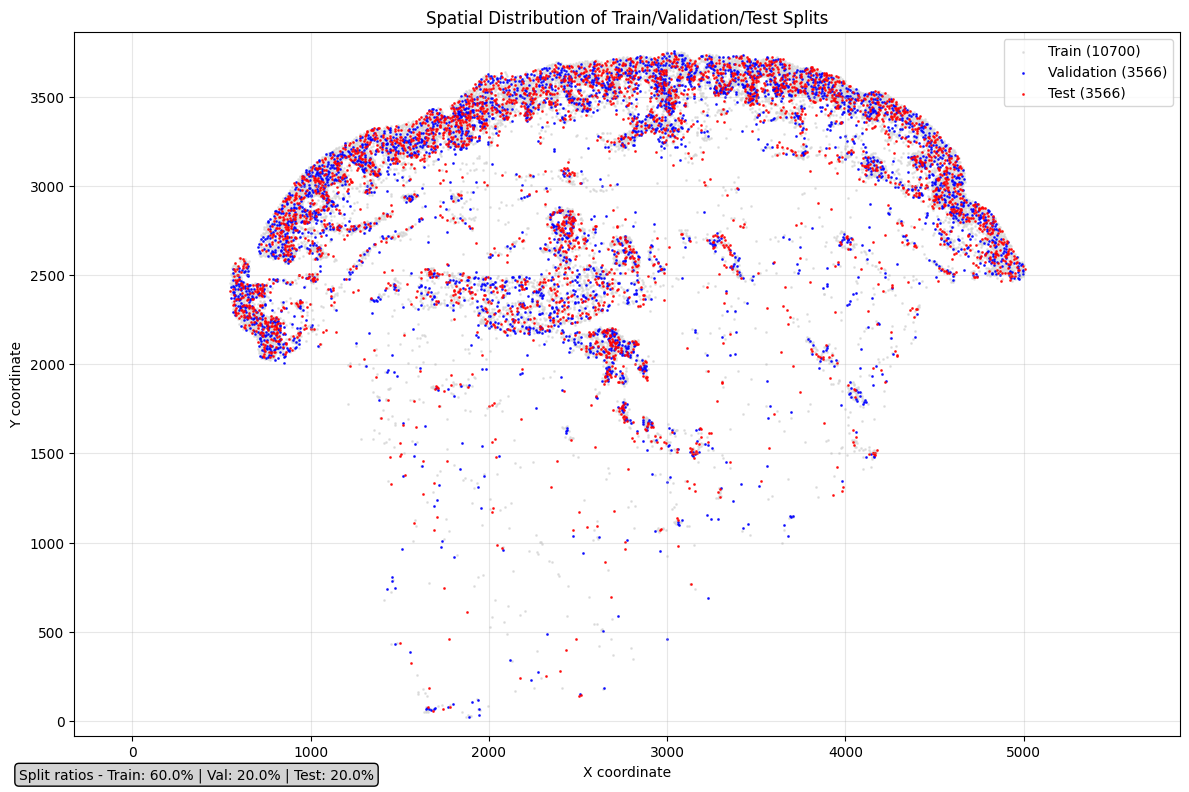

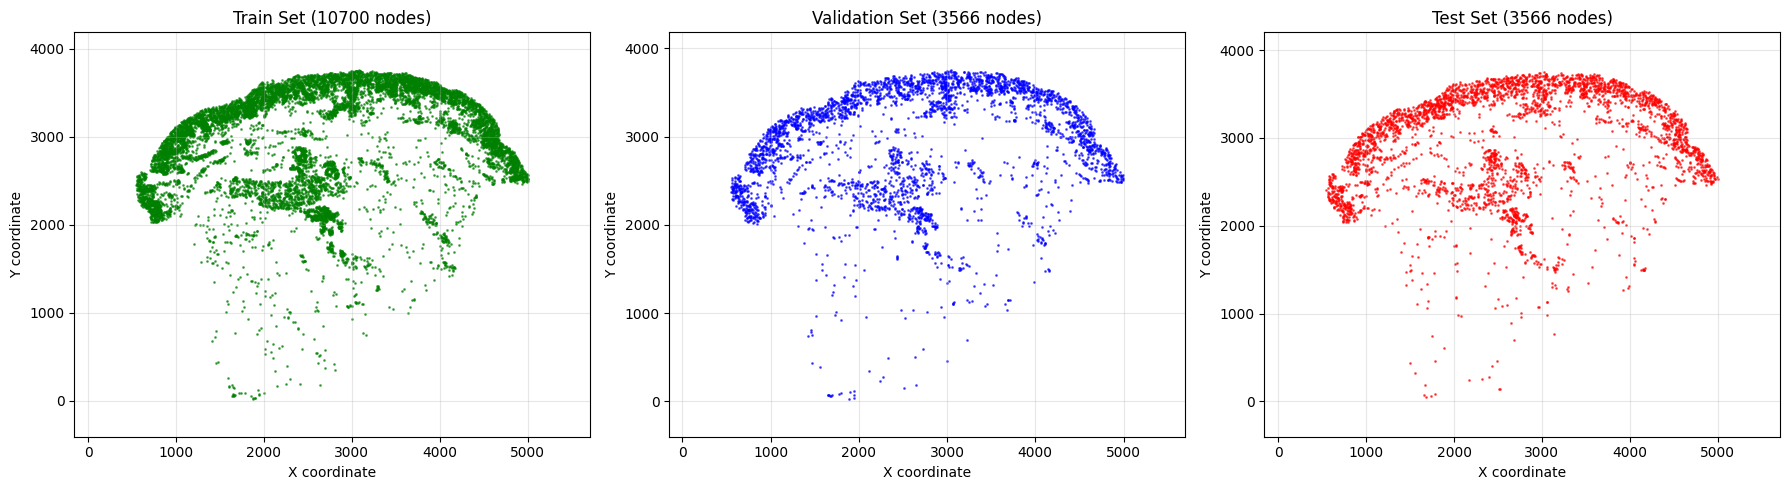

In [8]:
one_batch_train_val_test_splits(rdn_data_batch)

## Spatial Split

In [9]:
# Deep copy to preserve original
spatial_cfg = copy.deepcopy(cfg)

# Update nested keys
spatial_cfg['dataset'].update({
    'train_transform_names': ['SpatialNodeSplit'],
    'train_transform_params': {
        'val_region': {'x_min': 1000.0, 'x_max': 2000.0, 'y_min': 3000.0, 'y_max': 3500.0},
        'test_region': {'x_min': 3000.0, 'x_max': 4000.0, 'y_min': 3000.0, 'y_max': 3500.0},
        'xy_key': 'xy_coordinates'
    }
})

print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(spatial_cfg)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
spatial_data_batch = initialize_databatch(config=spatial_cfg, dataset_blob=dataset_blob)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
SpatialNodeSplit: Train=14771, Val=2276, Test=785
Total nodes assigned: 17832/17832
DataBatch(y_cell_types=[17832, 41], y_niche_types=[17832, 15], xy_coordinates=[17832, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[17832, 1000], y=[17832, 41], edge_index=[2, 183562], encoder_condition_dim=[1], attr_decoder_conditions=[17832, 8], attr_decoder_condition_dim=[1], adj_decoder_condition_dim=[1], num_features=[1], num_classes=[1], num_nodes=17832, num_edges=[1], train_mask=[17832], val_mask=[17832], test_mask=[17832], batch=[17832], ptr=[2])
Batch ID(s): [11]
Data Batch: DataBatch(y_cell_types=[17832, 41], y_niche_types=[17832, 15], xy_coordinates=[17832, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[17832, 1000], y=[17832, 41], edge_index=[2, 183562], encoder_condition_dim=0, attr_decoder_conditions=[17832, 8], attr_decoder_conditio

Extracting data attributes...
Data batch keys: ['dataset_id', 'adj_decoder_condition_dim', 'x', 'encoder_condition_dim', 'num_features', 'attr_decoder_conditions', 'train_mask', 'cell_id', 'val_mask', 'attr_decoder_condition_dim', 'y', 'y_niche_types', 'xy_coordinates', 'y_cell_types', 'num_edges', 'ptr', 'num_classes', 'num_nodes', 'edge_index', 'adata_batch_id', 'batch', 'species', 'test_mask', 'tissue']
Number of nodes: 17832
Number of features: 1000
Number of edges: 183562
Train nodes: 14771
Val nodes: 2276
Test nodes: 785
Total nodes: 17832


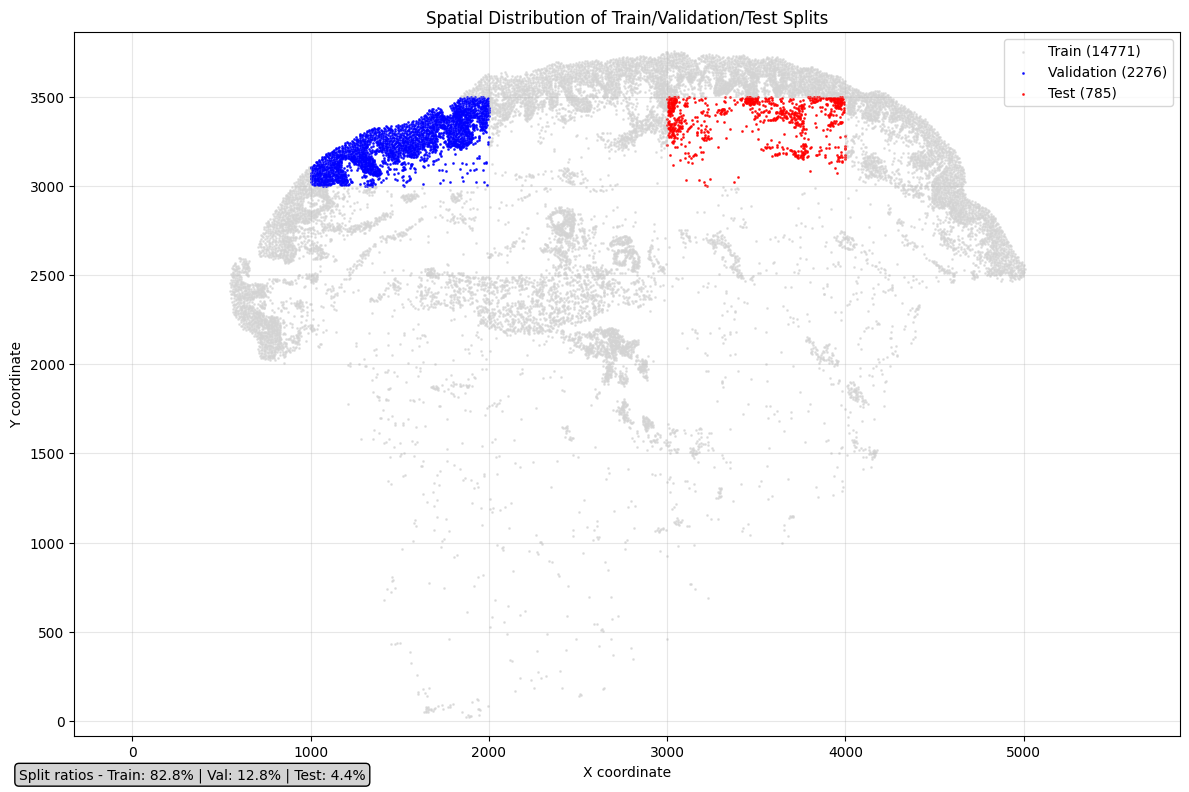

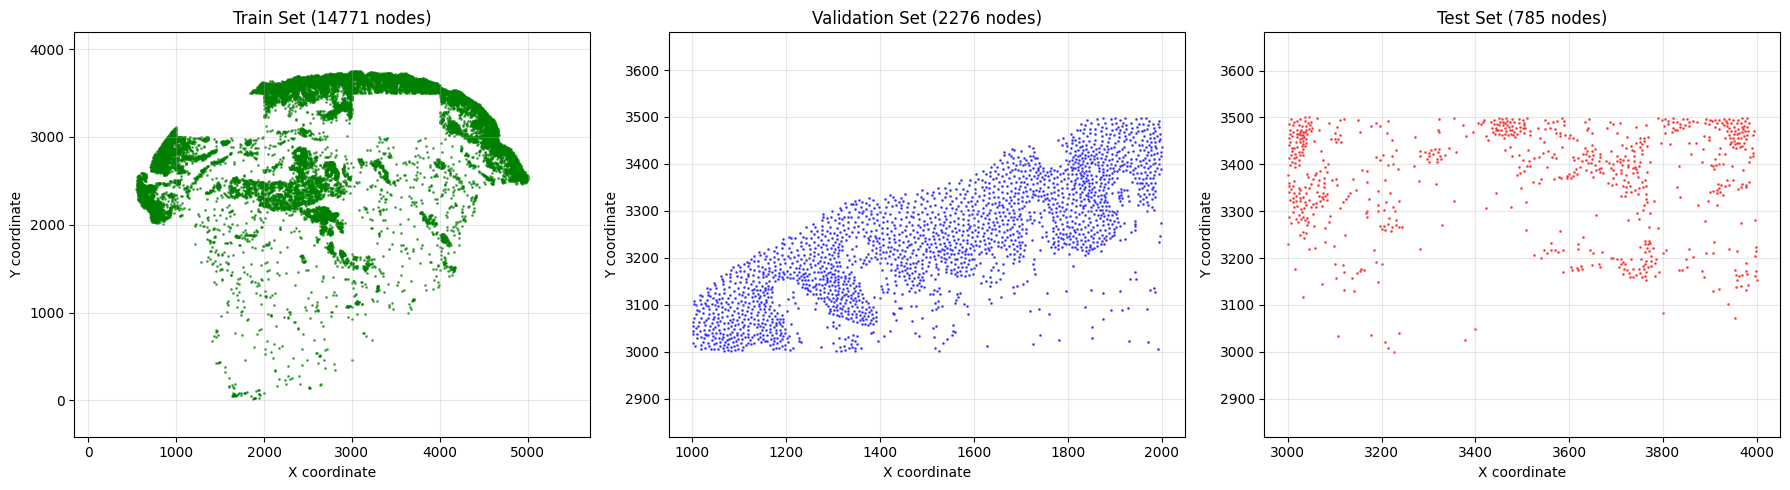

In [10]:
one_batch_train_val_test_splits(spatial_data_batch)

## Three Batches

In [24]:
def three_batch_train_val_test_splits(data_batch):
    # Assumes data_batch is a PyG Batch with 3 graphs
    # Colors: light for train, blue for val, red for test
    colors = {'train': '#d3d3d3', 'val': 'blue', 'test': 'red'}

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # If ptr is unavailable, fall back to batch vector
    use_ptr = hasattr(data_batch, 'ptr') and data_batch.ptr is not None

    for i, ax in enumerate(axes):
        if use_ptr:
            start = int(data_batch.ptr[i])
            end = int(data_batch.ptr[i+1])
            idx = torch.arange(start, end, device=data_batch.xy_coordinates.device)
        else:
            idx = (data_batch.batch == i).nonzero(as_tuple=True)[0]

        coords = data_batch.xy_coordinates[idx].cpu()
        train = data_batch.train_mask[idx].cpu()
        val = data_batch.val_mask[idx].cpu()
        test = data_batch.test_mask[idx].cpu()

        # Plot train under val/test for visibility
        if train.any():
            ax.scatter(coords[train, 0], coords[train, 1], s=5, c=colors['train'], label='train')
        if val.any():
            ax.scatter(coords[val, 0], coords[val, 1], s=5, c=colors['val'], label='val')
        if test.any():
            ax.scatter(coords[test, 0], coords[test, 1], s=5, c=colors['test'], label='test')

        ax.set_title(f'Batch {data_batch.adata_batch_id[i]}')
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])

    # Put a single legend on the right
    axes[-1].legend(loc='lower right', frameon=False)
    plt.show()

In [13]:
three_cfg_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b-batch11-12-13_1p_vqniche_graphsage.yaml")
with open(three_cfg_file, 'r') as f:
    three_cfg = yaml.safe_load(f)

In [14]:
# Deep copy to preserve original
spatial_batch_cfg = copy.deepcopy(three_cfg)

# Update nested keys
spatial_batch_cfg['dataset'].update({
    'train_transform_names': ['SpatialBatchSplit'],
    'train_transform_params': {
        'region': {'x_min': 1000.0, 'x_max': 2000.0, 'y_min': 3000.0, 'y_max': 3500.0},
        'xy_key': 'xy_coordinates',
        'train_batches': [11],
        'val_batches': [12],
        'test_batches': [13],        
    }
})

print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(spatial_batch_cfg)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
spatial_data_batch = initialize_databatch(config=spatial_batch_cfg, dataset_blob=dataset_blob)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
SubsetHVG: Subsetted data to 1000 features.
SubsetHVG: Subsetted data to 1000 features.
DataBatch(y_cell_types=[46893, 41], y_niche_types=[46893, 15], xy_coordinates=[46893, 2], cell_id=[3], dataset_id=[3], tissue=[3], species=[3], adata_batch_id=[3], x=[46893, 1000], y=[46893, 41], edge_index=[2, 488979], encoder_conditions=[46893, 2], encoder_condition_dim=[3], attr_decoder_conditions=[46893, 2], attr_decoder_condition_dim=[3], adj_decoder_condition_dim=[3], num_features=[3], num_classes=[3], num_nodes=46893, num_edges=[3], train_mask=[46893], val_mask=[46893], test_mask=[46893], batch=[46893], ptr=[4])
Batch ID(s): [11, 12, 13]
Data Batch: DataBatch(y_cell_types=[46893, 41], y_niche_types=[46893, 15], xy_coordinates=[46893, 2], cell_id=[3], dataset_id=[3], tissue=[3], species=[3], adata_batch_id=[3], x=[46893, 1000], y=[46893, 41], edge_index=[2, 488979], encoder_conditions=[46893, 2], encoder_

In [28]:
dataset_blob[11].adata_batch_id

SubsetHVG: Subsetted data to 1000 features.


tensor([11])

In [29]:
dataset_blob[12].adata_batch_id

SubsetHVG: Subsetted data to 1000 features.


tensor([12])

In [27]:
spatial_data_batch.adata_batch_id

tensor([11, 24, 38])

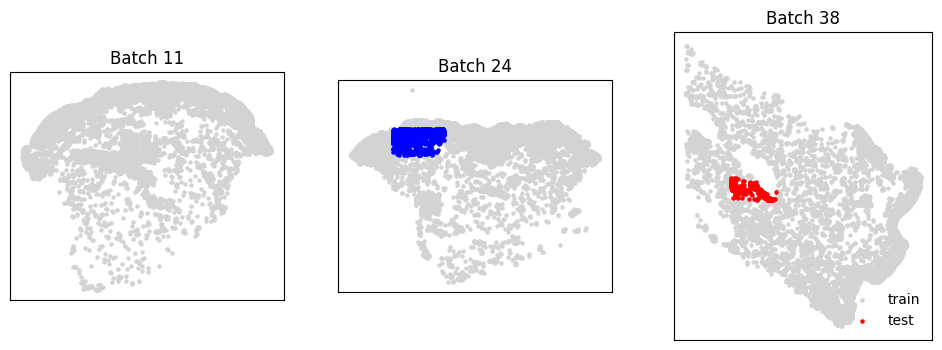

In [25]:
three_batch_train_val_test_splits(spatial_data_batch)